Equilibrium: phi*=0.625681, psi*=0.002430, r*=0.371889


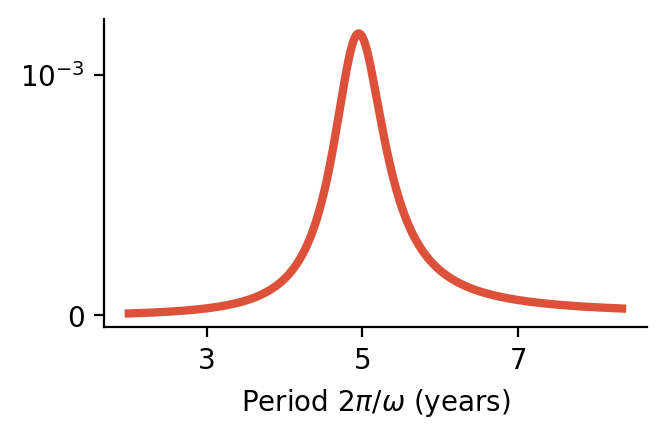

Peak period ≈ 257.6 weeks (4.95 years)


In [148]:
import numpy as np
import matplotlib.pyplot as plt

def DiscTimeRate(r, dt):
    return (1 - np.exp(-r*dt))/dt

# Parameters (time unit = weeks)
dt_discrete = 1/8.0
beta = DiscTimeRate(0.649645859, dt_discrete)   # transmission
gamma = DiscTimeRate(1/2.5, dt_discrete)        # recovery
mu =DiscTimeRate(1/(80*52), dt_discrete)        # birth/death
delta = DiscTimeRate(0.0023089227, dt_discrete) # waning
N = 100000

# Endemic equilibrium
phi_star = (mu + gamma) / beta
psi_star = ((mu + delta) * (1 - phi_star)) / (beta * phi_star + delta)
r_star = 1 - phi_star - psi_star
print(f"Equilibrium: phi*={phi_star:.6f}, psi*={psi_star:.6f}, r*={r_star:.6f}")

# Jacobian
a11 = -(mu + delta) - beta * psi_star
a12 = -(beta * phi_star + delta)
a21 = beta * psi_star
a22 = beta * phi_star - (mu + gamma)

# Noise covariance
f1 = beta * phi_star * psi_star
f2 = gamma * psi_star
f3 = mu * psi_star
f4 = mu * r_star
f5 = delta * r_star

B11 = f1 + f3 + f4 + f5
B12 = -(f1 + f3)
B22 = f1 + f2 + f3

# PSD quantities
Omega0_sq = a11*a22 - a12*a21
Gamma = -(a11 + a22)
alpha_I = a21**2 * B11 - 2*a11*a21*B12 + a11**2*B22

def PSD_I(omega):
    num = alpha_I + B22 * omega**2
    denom = (omega**2 - Omega0_sq)**2 + (Gamma**2) * (omega**2)
    return num / denom / N

# Frequency range 
f_min = 0.12/52
f_max = 0.5/52
omegas = np.linspace(2*np.pi*f_min, 2*np.pi*f_max, 5000)
psd_vals = [PSD_I(w) for w in omegas]


plt.figure(figsize=(3.5,2), dpi=200)
plt.plot(2*np.pi/(52*omegas), 1000*np.array(psd_vals), color=plt.cm.inferno(0.6), label=r"power, prevalence", lw=3) 
plt.xlabel(r"Period $2\pi/\omega$ (years)")
#plt.ylabel(r"$P(\omega)$")
plt.grid(False)
plt.yticks([0, 1], labels=['0', r'$10^{-3}$'])
plt.xticks([3, 5, 7])
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

# Dominant period
omega_peak = omegas[np.argmax(psd_vals)]
T_peak_weeks = 2*np.pi / omega_peak
print(f"Peak period ≈ {T_peak_weeks:.1f} weeks ({T_peak_weeks/52:.2f} years)")


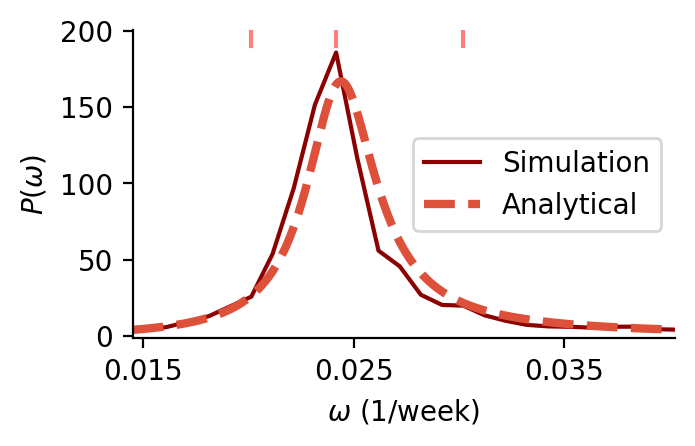

In [182]:
# Would also like to have a plot against omega, but with periods indicated:
plt.figure(figsize=(3.5,2), dpi=200)

omega3 = 2*np.pi/(3*52) 
omega5 = 2*np.pi/(5*52) # 5-year period
omega7 = 2*np.pi/(7*52) 
plt.xlabel(r"$\omega$ (1/week)")
#plt.ylabel(r"$P(\omega)$")
plt.grid(False)

#plt.yticks([0, 1], labels=['0', r'$10^{-3}$'])

plt.xlim([2*np.pi/(8.333*52), 2*np.pi/(3*52)])

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Also read in Gillespie PSD results:

data = np.loadtxt("data/psd_output.txt")
omegas_gil = data[:,0]/52
psd_gil = data[:,1]

# Rescale the Gillespie version so they are densities on the same domain:
om_range_mask = np.where(np.logical_and(omegas_gil >= np.min(omegas), omegas_gil <= np.max(omegas)))
psd_gil /= np.mean(psd_gil[om_range_mask]) * (np.max(omegas) - np.min(omegas))
plt.plot(omegas_gil[om_range_mask], psd_gil[om_range_mask], color="darkred", label="Simulation")

psd_vals = np.array(psd_vals)
psd_vals /= np.mean(psd_vals) * (np.max(omegas) - np.min(omegas))

plt.plot(omegas, psd_vals, color=plt.cm.inferno(0.6), lw=3, ls="--", label="Analytical") 
plt.ylabel(r"$P(\omega)$")

plt.xticks([0.015, 0.025, 0.035])


ymin = -0.01*np.max(psd_vals)
ymax = 1.2*np.max(psd_vals)
plt.ylim([ymin, ymax])


plt.plot([2*np.pi/(4*52), 2*np.pi/(4*52)], [0.95*ymax, ymax], ls="-", color="red", alpha=0.5)
plt.plot([2*np.pi/(5*52), 2*np.pi/(5*52)], [0.95*ymax, ymax], ls="-", color="red", alpha=0.5)
plt.plot([2*np.pi/(6*52), 2*np.pi/(6*52)], [0.95*ymax, ymax], ls="-", color="red", alpha=0.5)

plt.legend(loc="center right")

# Heatmaps (supplement)

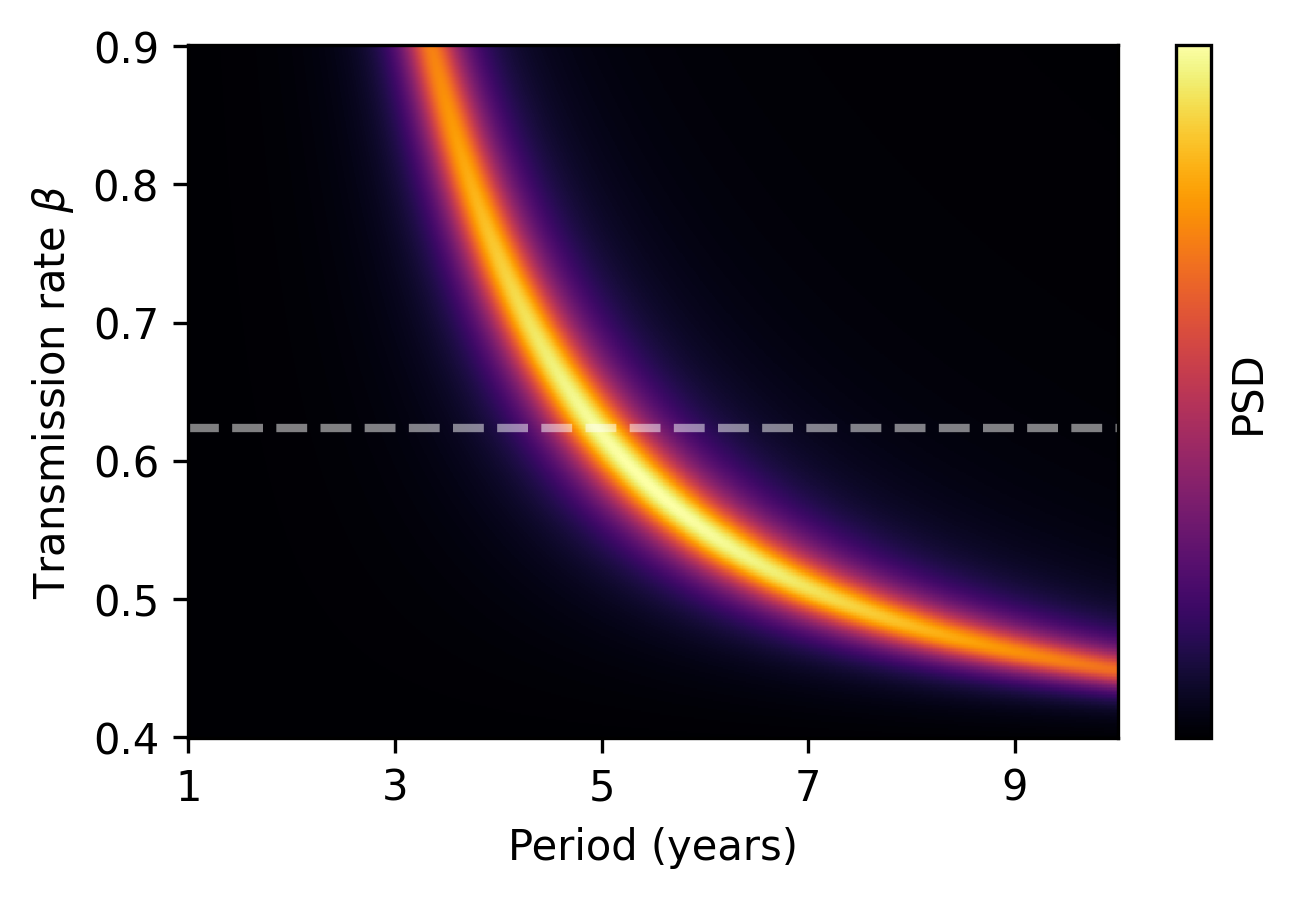

In [43]:
beta0 = DiscTimeRate(0.649645859, dt_discrete)   # transmission
gamma0 = DiscTimeRate(1/2.5, dt_discrete)        # recovery
mu0 =DiscTimeRate(1/(80*52), dt_discrete)        # birth/death
delta0 = DiscTimeRate(0.0023089227, dt_discrete) # waning

# Fixed parameters
gamma = gamma0
mu = mu0
delta = delta0
N = 100000

omegas = np.linspace(1e-3, 1/(2*np.pi), 5000)

# Period in years
periods = (2*np.pi / omegas) / 52

# Beta values to scan
betas = np.linspace(0.4, 0.9, 500)

PSD_matrix = np.zeros((len(betas), len(omegas)))

for ib, beta in enumerate(betas):
    phi_star = (mu + gamma) / beta
    psi_star = ((mu + delta) * (1 - phi_star)) / (beta * phi_star + delta)
    r_star = 1 - phi_star - psi_star

    a11 = -(mu + delta) - beta * psi_star
    a12 = -(beta * phi_star + delta)
    a21 = beta * psi_star
    a22 = beta * phi_star - (mu + gamma)

    f1 = beta * phi_star * psi_star
    f2 = gamma * psi_star
    f3 = mu * psi_star
    f4 = mu * r_star
    f5 = delta * r_star

    B11 = f1 + f3 + f4 + f5
    B12 = -(f1 + f3)
    B22 = f1 + f2 + f3

    Omega0_sq = a11*a22 - a12*a21
    Gamma = -(a11 + a22)
    alpha_I = a21**2 * B11 - 2*a11*a21*B12 + a11**2*B22

    PSD = (alpha_I + B22*omegas**2) / ((omegas**2 - Omega0_sq)**2 + (Gamma**2)*(omegas**2))
    PSD /= N  
    PSD_matrix[ib, :] = PSD

plt.figure(figsize=(5,3), dpi=300)
plt.pcolormesh(periods, betas, PSD_matrix, shading="auto", cmap="inferno")
plt.colorbar(label="PSD", ticks=[])
plt.xlabel("Period (years)")
plt.ylabel(r"Transmission rate $\beta$")
plt.xlim([1, 10])
plt.xticks([1, 3, 5, 7, 9])
plt.axhline(beta0, ls="--", color="white", lw=2, alpha=0.5)
plt.show()

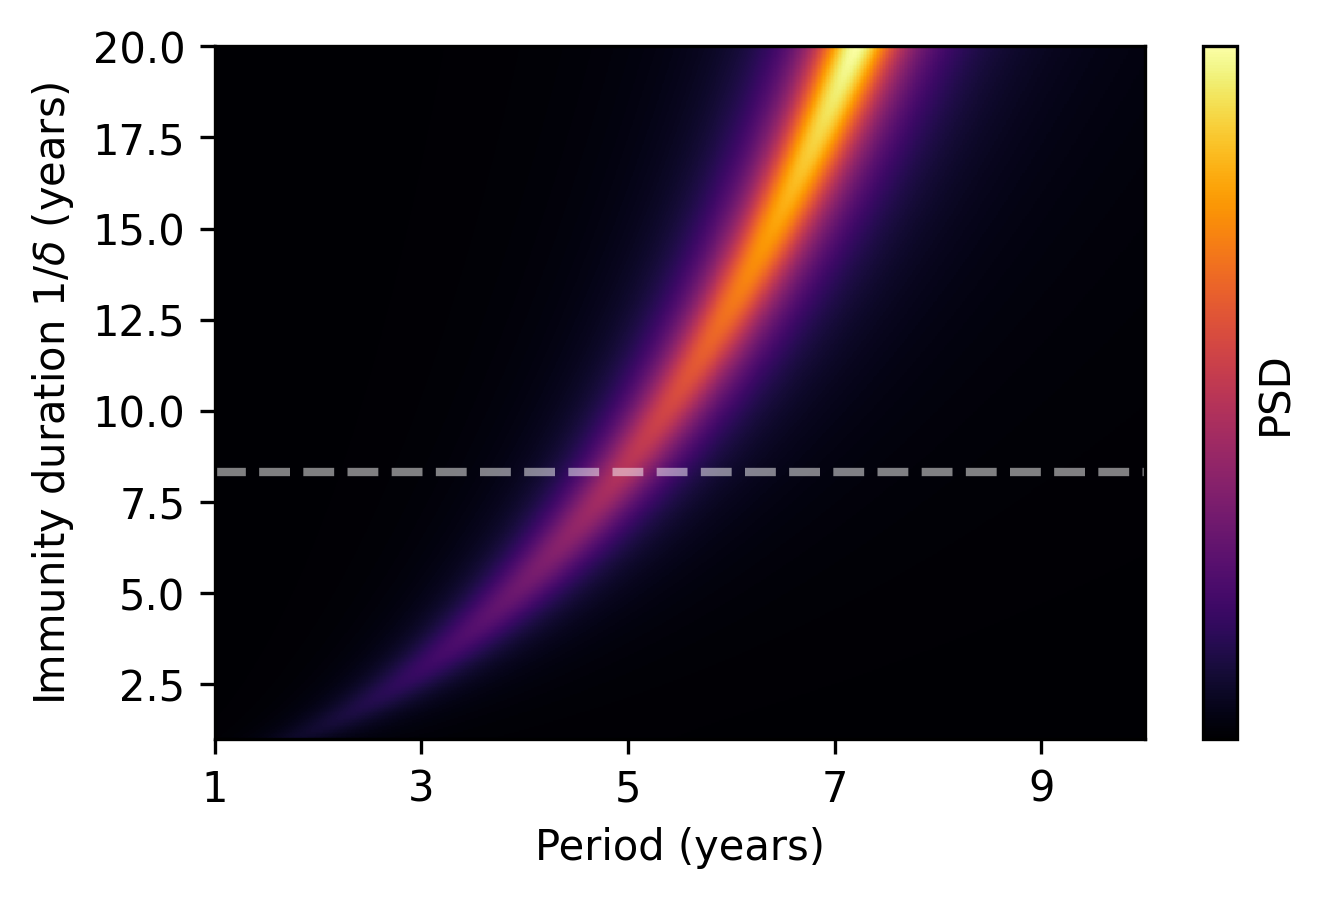

In [51]:
# Varying delta

# Fixed parameters
beta = beta0
gamma = gamma0
mu = mu0
N = 100000

omegas = np.linspace(1e-3, 1/(2*np.pi), 5000)

periods = (2*np.pi / omegas) / 52

imm_durations = np.linspace(1, 20, 500) # Years
y = imm_durations

PSD_matrix = np.zeros((len(betas), len(omegas)))

for ib, imm_dur in enumerate(y):
    delta = 1/(52*imm_dur)
    
    phi_star = (mu + gamma) / beta
    psi_star = ((mu + delta) * (1 - phi_star)) / (beta * phi_star + delta)
    r_star = 1 - phi_star - psi_star

    a11 = -(mu + delta) - beta * psi_star
    a12 = -(beta * phi_star + delta)
    a21 = beta * psi_star
    a22 = beta * phi_star - (mu + gamma)

    f1 = beta * phi_star * psi_star
    f2 = gamma * psi_star
    f3 = mu * psi_star
    f4 = mu * r_star
    f5 = delta * r_star

    B11 = f1 + f3 + f4 + f5
    B12 = -(f1 + f3)
    B22 = f1 + f2 + f3

    Omega0_sq = a11*a22 - a12*a21
    Gamma = -(a11 + a22)
    alpha_I = a21**2 * B11 - 2*a11*a21*B12 + a11**2*B22

    PSD = (alpha_I + B22*omegas**2) / ((omegas**2 - Omega0_sq)**2 + (Gamma**2)*(omegas**2))
    PSD /= N  
    PSD_matrix[ib, :] = PSD

plt.figure(figsize=(5,3), dpi=300)
plt.pcolormesh(periods, y, PSD_matrix, shading="auto", cmap="inferno")
plt.colorbar(label="PSD", ticks=[])
plt.xlabel("Period (years)")
plt.ylabel(r"Immunity duration $1/\delta$ (years)")
plt.xlim([1, 10])  
plt.ylim([np.min(y), np.max(y)])  
plt.xticks([1, 3, 5, 7, 9])
plt.axhline(1/(52*delta0), ls="--", color="white", lw=2, alpha=0.5)
plt.show()

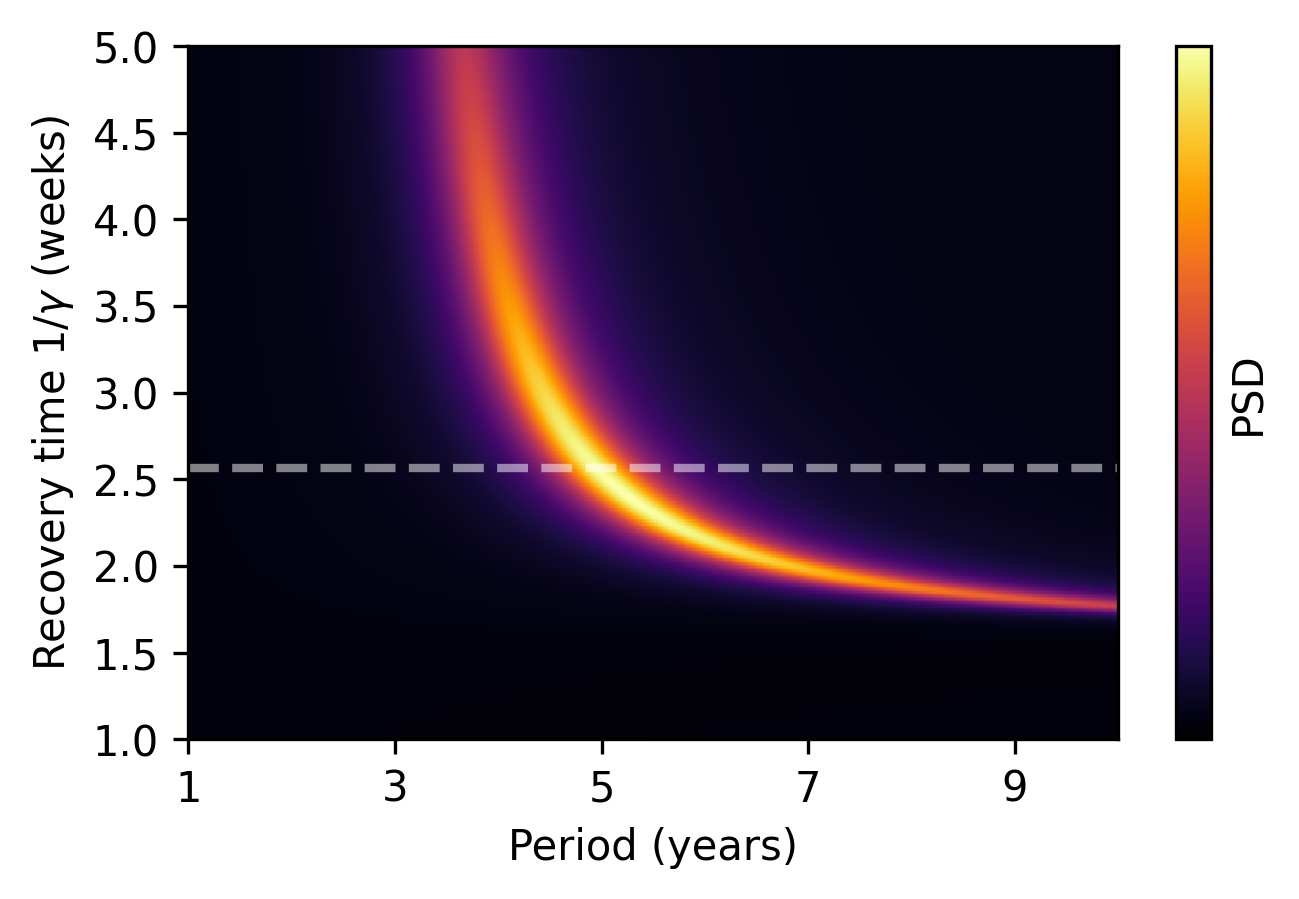

In [191]:
# Varying gamma

# Fixed parameters
beta = beta0
delta = delta0
mu = mu0
N = 100000

omegas = np.linspace(1e-3, 1/(2*np.pi), 5000)

periods = (2*np.pi / omegas) / 52

inf_durations = np.linspace(1, 5, 500) 

y = inf_durations

PSD_matrix = np.zeros((len(betas), len(omegas)))

for ib, y_loc in enumerate(y):
    gamma = 1/y_loc
    phi_star = (mu + gamma) / beta
    psi_star = ((mu + delta) * (1 - phi_star)) / (beta * phi_star + delta)
    r_star = 1 - phi_star - psi_star

    a11 = -(mu + delta) - beta * psi_star
    a12 = -(beta * phi_star + delta)
    a21 = beta * psi_star
    a22 = beta * phi_star - (mu + gamma)

    f1 = beta * phi_star * psi_star
    f2 = gamma * psi_star
    f3 = mu * psi_star
    f4 = mu * r_star
    f5 = delta * r_star

    B11 = f1 + f3 + f4 + f5
    B12 = -(f1 + f3)
    B22 = f1 + f2 + f3

    Omega0_sq = a11*a22 - a12*a21
    Gamma = -(a11 + a22)
    alpha_I = a21**2 * B11 - 2*a11*a21*B12 + a11**2*B22

    PSD = (alpha_I + B22*omegas**2) / ((omegas**2 - Omega0_sq)**2 + (Gamma**2)*(omegas**2))
    PSD /= N  
    PSD_matrix[ib, :] = PSD

plt.figure(figsize=(5,3), dpi=300)
plt.pcolormesh(periods, y, PSD_matrix, shading="auto", cmap="inferno")
plt.colorbar(label="PSD", ticks=[])
plt.xlabel("Period (years)")
plt.ylabel(r"Recovery time $1/\gamma$ (weeks)")
plt.xlim([1, 10])  
plt.ylim([np.min(y), np.max(y)]) 
plt.xticks([1, 3, 5, 7, 9])
plt.axhline(1/gamma0, ls="--", color="white", lw=2, alpha=0.5)
plt.show()

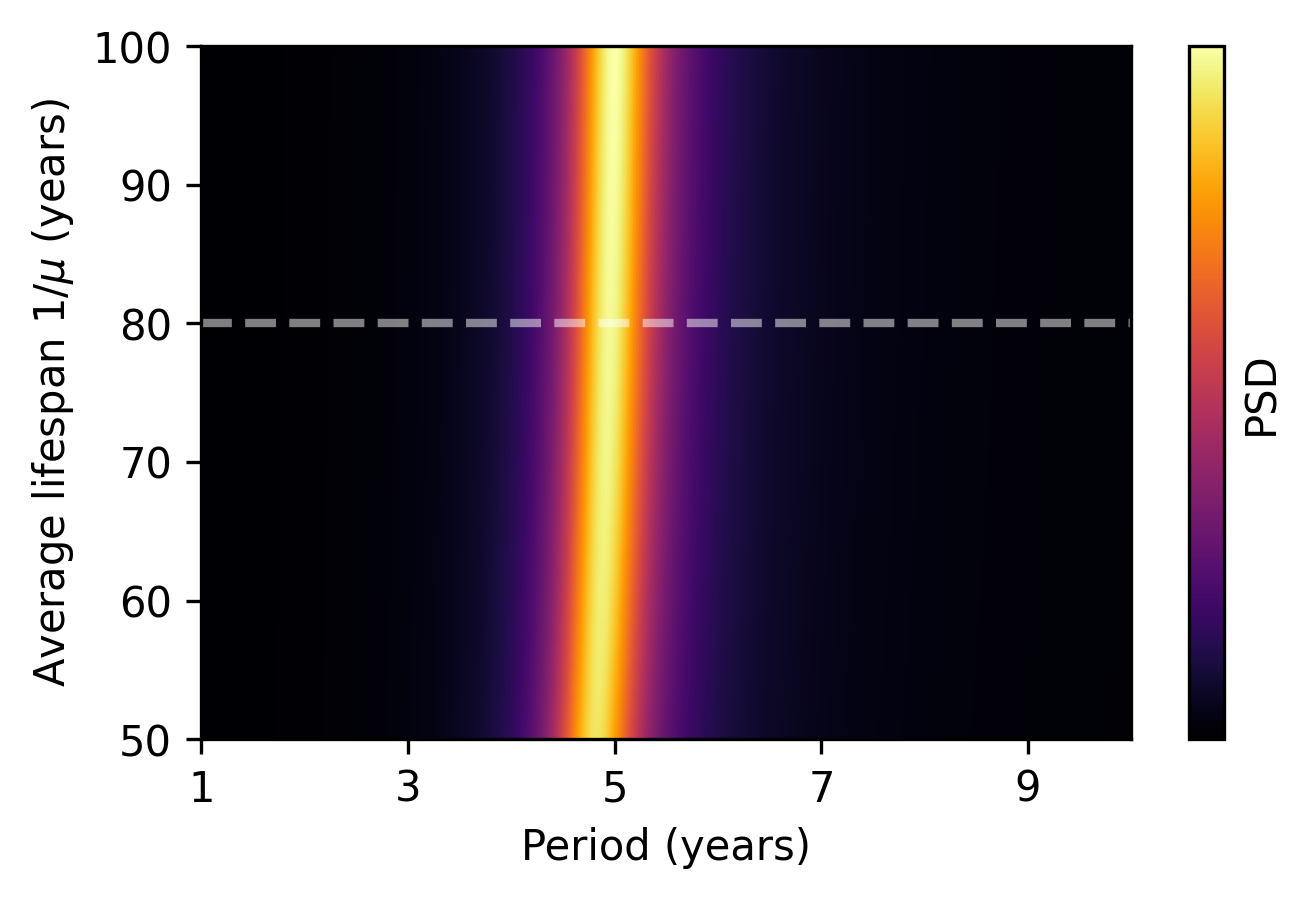

In [194]:
# Varying gamma

# Fixed parameters
beta = beta0
delta = delta0
gamma = gamma0
mu = mu0
N = 100000

omegas = np.linspace(1e-3, 1/(2*np.pi), 5000)

periods = (2*np.pi / omegas) / 52

lifespans = np.linspace(50, 100, 500) # weeks

y = lifespans

PSD_matrix = np.zeros((len(betas), len(omegas)))

for ib, y_loc in enumerate(y):
    mu = 1/(52*y_loc)
    phi_star = (mu + gamma) / beta
    psi_star = ((mu + delta) * (1 - phi_star)) / (beta * phi_star + delta)
    r_star = 1 - phi_star - psi_star

    a11 = -(mu + delta) - beta * psi_star
    a12 = -(beta * phi_star + delta)
    a21 = beta * psi_star
    a22 = beta * phi_star - (mu + gamma)

    f1 = beta * phi_star * psi_star
    f2 = gamma * psi_star
    f3 = mu * psi_star
    f4 = mu * r_star
    f5 = delta * r_star

    B11 = f1 + f3 + f4 + f5
    B12 = -(f1 + f3)
    B22 = f1 + f2 + f3

    Omega0_sq = a11*a22 - a12*a21
    Gamma = -(a11 + a22)
    alpha_I = a21**2 * B11 - 2*a11*a21*B12 + a11**2*B22

    PSD = (alpha_I + B22*omegas**2) / ((omegas**2 - Omega0_sq)**2 + (Gamma**2)*(omegas**2))
    PSD /= N 
    PSD_matrix[ib, :] = PSD

plt.figure(figsize=(5,3), dpi=300)
plt.pcolormesh(periods, y, PSD_matrix, shading="auto", cmap="inferno")
plt.colorbar(label="PSD", ticks=[])
plt.xlabel("Period (years)")
plt.ylabel(r"Average lifespan $1/\mu$ (years)")
plt.xlim([1, 10])  
plt.ylim([np.min(y), np.max(y)]) 
plt.xticks([1, 3, 5, 7, 9])
plt.axhline(1/(52*mu0), ls="--", color="white", lw=2, alpha=0.5)
plt.show()